In [1]:
# !rm -rf '/content/DIS_Hughen'
# !git clone https://github.com/NU-Academics/DIS_Hughen.git

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.manifold import TSNE
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
# df = pd.read_csv("/content/DIS_Hughen/undersampled_CIC2019_dataset.csv")

In [5]:
df.shape

(4685611, 90)

In [6]:
df["label"].value_counts()

label
TFTP             950295
DrDoS_NTP        917607
DrDoS_DNS        893762
DrDoS_SNMP       415000
DrDoS_LDAP       290000
LDAP             290000
MSSQL            190000
UDP              150000
DrDoS_MSSQL      150000
DrDoS_SSDP       106650
DrDoS_UDP        105000
DrDoS_NetBIOS     65000
NetBIOS           55057
BENIGN            53277
Syn               42004
Portmap            5608
UDP-lag            5000
UDPLag             1203
WebDDoS             148
Name: count, dtype: int64

In [7]:
dos_set = df[df["label"].str.contains("DoS", case=False, na=False)]
dos_sample = (dos_set.sample(n=50000, random_state=42, replace=False).reset_index(drop=True))
dos_sample["label"] = "DoS_ATTACK"
dos_sample["label"].value_counts()

label
DoS_ATTACK    50000
Name: count, dtype: int64

In [8]:
non_dos_set = df[(df["label"] != "BENIGN") & (~df["label"].str.contains("DoS", case=False, na=False))]
non_dos_sample = (non_dos_set.sample(n=50000, random_state=42, replace=False).reset_index(drop=True))
non_dos_sample["label"] = "NON_DoS_ATTACK"
non_dos_sample["label"].value_counts()

label
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [9]:
attack_sample =pd.concat([dos_sample, non_dos_sample]).reset_index(drop=True)
attack_sample["label"].value_counts()

label
DoS_ATTACK        50000
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [10]:
benign_set = df[df["label"] == "BENIGN"]
benign_sample = benign_set.sample(n=non_dos_sample.shape[0], replace=False, random_state=42)

In [11]:
benign_sample.shape

(50000, 90)

In [12]:
print(benign_sample["label"].value_counts())

label
BENIGN    50000
Name: count, dtype: int64


In [13]:
df_sample =pd.concat([benign_sample, attack_sample]).reset_index(drop=True)

In [14]:
df_sample.shape

(150000, 90)

In [15]:
df_sample["label"].value_counts()

label
BENIGN            50000
DoS_ATTACK        50000
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [16]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DoS_ATTACK': 1, 'NON_DoS_ATTACK': 2}


In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # 0.2
)

In [18]:
X_min_raw = X.min(axis=0).values
X_max_raw = X.max(axis=0).values

X_min_df = pd.DataFrame([X_min_raw], columns=X.columns)
X_max_df = pd.DataFrame([X_max_raw], columns=X.columns)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_min_scaled = scaler.transform(X_min_raw.reshape(1, -1)).flatten()
X_max_scaled = scaler.transform(X_max_raw.reshape(1, -1)).flatten()

x_min_t = torch.tensor(X_min_scaled, dtype=torch.float32, device=device)
x_max_t = torch.tensor(X_max_scaled, dtype=torch.float32, device=device)

C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [19]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=2048, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=2048)

In [20]:
input_size = 88
hidden_size = 128
num_classes = 3

class MultiClassDNN(nn.Module):
    def __init__(self, input_size=88, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), #256
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [21]:
model = MultiClassDNN().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [22]:
num_epochs = 50
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    avg_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
torch.save(model.state_dict(), "multiclass_dnn.pth")

Epoch 1, Train Loss: 0.6239, Val Loss: 0.4053
Epoch 2, Train Loss: 0.3848, Val Loss: 0.3703
Epoch 3, Train Loss: 0.3719, Val Loss: 0.3661
Epoch 4, Train Loss: 0.3684, Val Loss: 0.3641
Epoch 5, Train Loss: 0.3669, Val Loss: 0.3641
Epoch 6, Train Loss: 0.3647, Val Loss: 0.3621
Epoch 7, Train Loss: 0.3641, Val Loss: 0.3630
Epoch 8, Train Loss: 0.3632, Val Loss: 0.3606
Epoch 9, Train Loss: 0.3620, Val Loss: 0.3607
Epoch 10, Train Loss: 0.3617, Val Loss: 0.3592
Epoch 11, Train Loss: 0.3608, Val Loss: 0.3589
Epoch 12, Train Loss: 0.3603, Val Loss: 0.3587
Epoch 13, Train Loss: 0.3597, Val Loss: 0.3592
Epoch 14, Train Loss: 0.3591, Val Loss: 0.3591
Epoch 15, Train Loss: 0.3588, Val Loss: 0.3577
Epoch 16, Train Loss: 0.3583, Val Loss: 0.3576
Epoch 17, Train Loss: 0.3581, Val Loss: 0.3569
Epoch 18, Train Loss: 0.3578, Val Loss: 0.3581
Epoch 19, Train Loss: 0.3576, Val Loss: 0.3572
Epoch 20, Train Loss: 0.3572, Val Loss: 0.3569
Epoch 21, Train Loss: 0.3569, Val Loss: 0.3569
Epoch 22, Train Loss: 

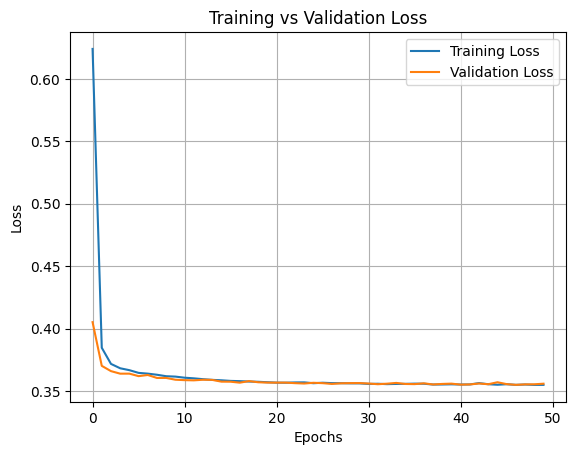

In [23]:
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [24]:
model.eval()
X_tensor = X_val_tensor.to(device)
y = y_val.values
with torch.no_grad():
    logits = model(X_tensor)
    y_prob = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

In [25]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Weighted F1:", f1_score(y, y_pred, average='weighted'))
print("Macro F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.8904888888888889
Weighted F1: 0.8904347690267529
Macro F1: 0.8904347690267529
ROC-AUC: 0.9704094455555555


In [26]:
print(classification_report(y, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     15000
    DoS_ATTACK       0.83      0.85      0.84     15000
NON_DoS_ATTACK       0.84      0.83      0.83     15000

      accuracy                           0.89     45000
     macro avg       0.89      0.89      0.89     45000
  weighted avg       0.89      0.89      0.89     45000



In [27]:
import math 

cont_idx = [0, 1, 2, 3, 4]
bin_idx = [5, 6, 7]
cat_groups = [[8, 9, 10], [11, 12, 13]]

def pgd_attack(model, x, y, epsilon=0.1, alpha=0.02, num_steps=200, n_restarts=5, momentum=0.9, x_min=None, x_max=None, target_class=None, verbose=False):
    model.eval()
    device = next(model.parameters()).device
    if not isinstance(x, torch.Tensor): x = torch.tensor(x, dtype=torch.float32)
    if not isinstance(y, torch.Tensor): y = torch.tensor(np.array(y), dtype=torch.long)
    x = x.to(device)
    y = y.to(device)
    if x_min is not None: x_min = x_min.clone().detach().to(device=device, dtype=torch.float32)
    if x_max is not None: x_max = x_max.clone().detach().to(device=device, dtype=torch.float32)
    cont_idx_t = torch.tensor(cont_idx, device=device)
    bin_idx_t  = torch.tensor(bin_idx, device=device) if bin_idx else None
    N = x.size(0)
    num_classes = model(x[:1]).shape[1]
    best_is_fooled = torch.zeros(N, dtype=torch.bool, device=device)
    best_loss      = torch.full((N,), -float("inf"), device=device)
    best_x_adv     = x.clone()
    for restart in range(n_restarts):
        with torch.no_grad():
            init_logits = model(x)
            masked = init_logits.clone()
            masked.scatter_(1, y.unsqueeze(1), -1e9)
            second_class = masked.argmax(dim=1)           # (N,)
        delta = torch.zeros_like(x)
        delta[:, cont_idx] = torch.empty(N, len(cont_idx), device=device).uniform_(-epsilon * 0.5, epsilon * 0.5)
        x_tmp = x.detach().requires_grad_(True)
        guide_loss = F.cross_entropy(model(x_tmp), second_class)
        guide_loss.backward()
        with torch.no_grad():
            g = x_tmp.grad.detach()
            g_sign = torch.sign(g)
            delta[:, cont_idx_t] += 0.5 * epsilon * g_sign[:, cont_idx_t]
            delta[:, cont_idx_t].clamp_(-epsilon, epsilon)
        x_adv = (x + delta).clamp_(*((x_min, x_max) if x_min is not None else (-1e9, 1e9))).clone()
        use_cw_loss = (restart % 2 == 1)
        grad_momentum = torch.zeros_like(x)
        if target_class is None:
            with torch.no_grad():
                tgt_logits = model(x_adv)
                tgt_masked = tgt_logits.clone()
                tgt_masked.scatter_(1, y.unsqueeze(1), -1e9)
                # Vary which wrong class we target across restarts
                sorted_wrong = tgt_masked.argsort(dim=1, descending=True)
                target_vec = sorted_wrong[:, restart % (num_classes - 1)]  # rotate targets
        still_alive = torch.ones(N, dtype=torch.bool, device=device)
        for step in range(num_steps):
            if still_alive.sum() == 0: break
            x_adv_alive = x_adv[still_alive].detach().requires_grad_(True)
            y_alive     = y[still_alive]

            logits = model(x_adv_alive)

            if target_class is not None:
                t = torch.full_like(y_alive, target_class)
                if use_cw_loss:
                    correct_logit = logits.gather(1, y_alive.unsqueeze(1)).squeeze(1)
                    target_logit  = logits.gather(1, t.unsqueeze(1)).squeeze(1)
                    loss = (correct_logit - target_logit).mean()
                else:
                    loss = -F.cross_entropy(logits, t)
            else:
                tv = target_vec[still_alive]
                if use_cw_loss:
                    correct_logit = logits.gather(1, y_alive.unsqueeze(1)).squeeze(1)
                    target_logit  = logits.gather(1, tv.unsqueeze(1)).squeeze(1)
                    loss = (correct_logit - target_logit).mean()
                else:
                    loss = F.cross_entropy(logits, y_alive) + F.cross_entropy(logits, tv)
            model.zero_grad(set_to_none=True)
            loss.backward()
            raw_grad = x_adv_alive.grad.detach()
            l1_norm = raw_grad.abs().sum(dim=1, keepdim=True).clamp(min=1e-12)
            grad_momentum[still_alive] = (momentum * grad_momentum[still_alive] + raw_grad / l1_norm)
            grad_sign = torch.sign(grad_momentum[still_alive])
            alpha_t = alpha * (0.3 + 0.7 * (1 + math.cos(math.pi * step / num_steps)) / 2)
            x_adv_step = x_adv[still_alive].detach()
            x_adv_step[:, cont_idx_t] = x_adv_step[:, cont_idx_t] + alpha_t * grad_sign[:, cont_idx_t]
            x_adv_step[:, cont_idx_t] = torch.max(torch.min(x_adv_step[:, cont_idx_t], 
            torch.min(x[:, cont_idx_t][still_alive] + epsilon, x_max_t[cont_idx_t].unsqueeze(0))),
            torch.max(x[:, cont_idx_t][still_alive] - epsilon, x_min_t[cont_idx_t].unsqueeze(0)))
            if bin_idx_t is not None and len(bin_idx) > 0:
                flip_mask = grad_sign[:, bin_idx_t] > 0
                x_adv_step[:, bin_idx_t] = torch.where(flip_mask, torch.ones_like(x_adv_step[:, bin_idx_t]), torch.zeros_like(x_adv_step[:, bin_idx_t]))
                x_adv_step[:, bin_idx_t] = torch.clamp(x_adv_step[:, bin_idx_t], x_min_t[bin_idx_t], x_max_t[bin_idx_t])             
            if cat_groups is not None:
                for group in cat_groups:
                    logits_cat = x_adv_step[:, group] + alpha_t * grad_sign[:, group]
                    best_cat = torch.argmax(logits_cat, dim=1)
                    one_hot = torch.zeros_like(logits_cat)
                    one_hot[torch.arange(still_alive.sum()), best_cat] = 1.0
                    x_adv_step[:, group] = one_hot
                    valid = ((x_min_t[group] <= x_adv_step[:, group]) & (x_adv_step[:, group] <= x_max_t[group])).all(dim=1, keepdim=True)
                    x_adv_step[:, group] = torch.where(valid.expand_as(x_adv_step[:, group]), x_adv_step[:, group], x[still_alive][:, group])                   
            if x_min is not None and x_max is not None:
                x_adv_step = torch.clamp(x_adv_step, x_min, x_max)
            x_adv[still_alive] = x_adv_step
            with torch.no_grad():
                preds_alive = model(x_adv[still_alive]).argmax(dim=1)
                newly_fooled = still_alive.clone()
                newly_fooled[still_alive] = (preds_alive != y[still_alive])
                still_alive[newly_fooled] = False   # stop updating them
        with torch.no_grad():
            logits_final = model(x_adv)
            preds_final  = logits_final.argmax(dim=1)
            fooled_now   = (preds_final != y)

            if target_class is not None:
                per_loss = -F.cross_entropy(logits_final,
                    torch.full_like(y, target_class), reduction="none")
            else:
                per_loss = F.cross_entropy(logits_final, y, reduction="none")
        update_mask = (
            (fooled_now & ~best_is_fooled)           # newly fooled → always update
            | (fooled_now & best_is_fooled & (per_loss > best_loss))   # both fooled, better loss
            | (~fooled_now & ~best_is_fooled & (per_loss > best_loss)) # neither fooled, better loss
        )
        best_is_fooled = torch.where(update_mask, fooled_now, best_is_fooled)
        best_loss = torch.where(update_mask, per_loss, best_loss)
        best_x_adv = torch.where(update_mask.unsqueeze(1).expand_as(x_adv), x_adv, best_x_adv)
        if verbose:
            fool_rate = fooled_now.float().mean().item()
            print(f"  Restart {restart+1}/{n_restarts} | α={alpha_t:.4f} | "
                  f"loss={'CW' if use_cw_loss else 'CE'} | "
                  f"fool_rate={fool_rate:.3f} | "
                  f"cumulative_fool={best_is_fooled.float().mean():.3f}")
    return best_x_adv.detach()

In [28]:
def epsilon_eval(model, X_val_tensor, y_val_tensor, epsilon, le=None, n_restarts=5, momentum=0.9, verbose=True, x_min=None, x_max=None):
    x_adv = pgd_attack(model, X_val_tensor, y_val_tensor, epsilon=epsilon, n_restarts=n_restarts, momentum=momentum, x_min=x_min, x_max=x_max, verbose=verbose)
    y_true = y_val_tensor.cpu().numpy()
    x_adv_np = x_adv.cpu().numpy()
    model.eval()
    with torch.no_grad():
        logits = model(x_adv.to(device))
        y_pred = torch.argmax(logits, dim=1).cpu().numpy()
    adv_df = pd.DataFrame(scaler.inverse_transform(x_adv_np), columns=X.columns).round(0).astype(int)
    adv_df["true_label"] = y_true
    adv_df["y_pred"] = y_pred
    filename = "adversarial_epsilon_" + str(epsilon) + ".csv"
    adv_df.to_csv(filename, index=False)
    print("=== ADVERSARIAL EVALUATION ===")
    print(f"Epsilon : {epsilon}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    tgt = le.classes_ if le is not None else None
    print(classification_report(y_true, y_pred, target_names=tgt))
for epsilon in [0.01, 0.05, 0.1, 0.5]:
    epsilon_eval(model, X_val_tensor, y_val_tensor, epsilon, le=le, n_restarts=5, momentum=0.9, verbose=True, x_min=x_min_t, x_max=x_max_t)

  Restart 1/5 | α=0.0060 | loss=CE | fool_rate=0.143 | cumulative_fool=0.143
  Restart 2/5 | α=0.0060 | loss=CW | fool_rate=0.130 | cumulative_fool=0.145
  Restart 3/5 | α=0.0060 | loss=CE | fool_rate=0.143 | cumulative_fool=0.145
  Restart 4/5 | α=0.0060 | loss=CW | fool_rate=0.130 | cumulative_fool=0.145
  Restart 5/5 | α=0.0060 | loss=CE | fool_rate=0.143 | cumulative_fool=0.145
=== ADVERSARIAL EVALUATION ===
Epsilon : 0.01
Accuracy: 0.8546
                precision    recall  f1-score   support

        BENIGN       1.00      0.95      0.97     15000
    DoS_ATTACK       0.80      0.78      0.79     15000
NON_DoS_ATTACK       0.78      0.83      0.80     15000

      accuracy                           0.85     45000
     macro avg       0.86      0.85      0.86     45000
  weighted avg       0.86      0.85      0.86     45000

  Restart 1/5 | α=0.0060 | loss=CE | fool_rate=0.142 | cumulative_fool=0.142
  Restart 2/5 | α=0.0060 | loss=CW | fool_rate=0.130 | cumulative_fool=0.144
  R